In [1]:
import random
from collections import deque
import gymnasium as gym
import ale_py
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import Video

gym.register_envs(ale_py)

In [2]:
class ReplayBuffer:
    """Stores transitions as uint8 to keep 50k of them in RAM.

    A float64 frame stack is 4*84*84*8 = 226 KB; with a state and a
    next_state per transition, a 50k buffer would need ~22 GB.  The same
    buffer in uint8 needs ~2.8 GB.
    """

    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, transition):
        self.memory.append(transition)

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [3]:
class DQN(nn.Module):
    def __init__(self, in_channels=4, num_actions=9):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512), nn.ReLU(),
            nn.Linear(512, num_actions),
        )

    def forward(self, x):
        return self.body(x)

In [4]:
class Pacman:
    def __init__(self, gamma=0.99, batch_size=32, env='ALE/MsPacman-v5',
                 num_frames=4, epsilon_start=1.0, epsilon_end=0.05,
                 epsilon_decay_steps=100_000, learning_starts=10_000,
                 train_freq=4, lr=1e-4, buffer_size=50_000,
                 clip_rewards=True, sticky_actions=False):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.env = gym.make(
            env, render_mode='rgb_array',
            repeat_action_probability=0.25 if sticky_actions else 0.0,
        )

        self.num_frames = num_frames
        self.gamma = gamma
        self.batch_size = batch_size
        self.learning_starts = learning_starts
        self.train_freq = train_freq
        self.clip_rewards = clip_rewards

        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay_steps = epsilon_decay_steps
        self.epsilon = epsilon_start

        n_actions = self.env.action_space.n
        self.policy = DQN(num_frames, n_actions).to(self.device)
        self.target = DQN(num_frames, n_actions).to(self.device)
        self.target.load_state_dict(self.policy.state_dict())
        self.target.eval()

        self.memory = ReplayBuffer(buffer_size)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.loss_fn = nn.HuberLoss()

        self.score_history, self.loss_history, self.q_history = [], [], []

    #  helpers 
    def preprocess(self, frame):
        """RGB (210,160,3) -> uint8 (84,84).  Stays uint8: normalisation
        happens in exactly one place, _to_tensor."""
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        return cv2.resize(frame, (84, 84), interpolation=cv2.INTER_AREA)

    def _to_tensor(self, stack):
        t = torch.as_tensor(np.asarray(stack), dtype=torch.float32, device=self.device)
        return t / 255.0

    def current_epsilon(self, step):
        frac = min(1.0, step / self.epsilon_decay_steps)
        return self.epsilon_start + frac * (self.epsilon_end - self.epsilon_start)

    def choose_best_action(self, state_stack, step):
        self.epsilon = self.current_epsilon(step)
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        with torch.no_grad():
            q = self.policy(self._to_tensor(state_stack).unsqueeze(0))
            return int(q.argmax(dim=1).item())

    # learning
    def fit_model(self, batch):
        states, actions, rewards, next_states, dones = zip(*batch)

        states = self._to_tensor(states)
        next_states = self._to_tensor(next_states)
        actions = torch.as_tensor(actions, dtype=torch.long, device=self.device)
        rewards = torch.as_tensor(rewards, dtype=torch.float32, device=self.device)
        dones = torch.as_tensor(dones, dtype=torch.float32, device=self.device)

        q_values = self.policy(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            max_next_q = self.target(next_states).max(dim=1)[0]
            target_q = rewards + self.gamma * max_next_q * (1 - dones)

        loss = self.loss_fn(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), 10.0)
        self.optimizer.step()

        return loss.item(), q_values.mean().item()

    # diagnostics
    @torch.no_grad()
    def collect_holdout(self, n=500):
        env = gym.make(self.env.spec.id, render_mode='rgb_array',
                       repeat_action_probability=0.0)
        states = []
        frame, _ = env.reset(seed=12345)
        stack = np.array([self.preprocess(frame)] * self.num_frames)
        while len(states) < n:
            nxt, _, term, trunc, _ = env.step(env.action_space.sample())
            stack = np.concatenate([stack[1:], [self.preprocess(nxt)]])
            states.append(stack.copy())
            if term or trunc:
                frame, _ = env.reset()
                stack = np.array([self.preprocess(frame)] * self.num_frames)
        env.close()
        return self._to_tensor(np.array(states))

    @torch.no_grad()
    def holdout_q(self):
        return self.policy(self.holdout).max(dim=1)[0].mean().item()

    # training loop
    def train(self, num_episodes=1000, update_target_freq=2500,
              max_steps_per_episode=10_000, log_every=10):
        self.holdout = self.collect_holdout()
        total_steps = 0

        try:
            self._loop(num_episodes, update_target_freq,
                       max_steps_per_episode, log_every, total_steps)
        except KeyboardInterrupt:
            print(f'\ninterrupted after {len(self.score_history)} episodes')
        self.save_history()
        return self

    def _loop(self, num_episodes, update_target_freq,
              max_steps_per_episode, log_every, total_steps):
        for episode in range(num_episodes):
            frame, _ = self.env.reset()
            state_stack = np.array([self.preprocess(frame)] * self.num_frames)

            episode_reward = 0.0
            episode_loss, loss_count, q_sum = 0.0, 0, 0.0
            done, steps = False, 0

            while not done and steps < max_steps_per_episode:
                action = self.choose_best_action(state_stack, total_steps)
                next_frame, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                next_stack = np.concatenate(
                    [state_stack[1:], [self.preprocess(next_frame)]]
                )

                stored_reward = np.sign(reward) if self.clip_rewards else reward
                self.memory.push((state_stack, action, stored_reward,
                                  next_stack, float(terminated)))

                episode_reward += reward          # report the true game score
                steps += 1
                total_steps += 1
                if (len(self.memory) >= self.learning_starts
                        and total_steps % self.train_freq == 0):
                    loss, qmean = self.fit_model(self.memory.sample(self.batch_size))
                    episode_loss += loss
                    q_sum += qmean
                    loss_count += 1

                if total_steps % update_target_freq == 0:
                    self.target.load_state_dict(self.policy.state_dict())

                state_stack = next_stack

            avg_loss = episode_loss / loss_count if loss_count else 0.0
            avg_q = q_sum / loss_count if loss_count else 0.0
            self.score_history.append(episode_reward)
            self.loss_history.append(avg_loss)
            self.q_history.append(self.holdout_q() if loss_count else 0.0)
            if abs(avg_q) > 1e4:
                print(f'DIVERGED at episode {episode}: mean Q = {avg_q:.3g}')
                break

            if episode % log_every == 0:
                print(f'Ep {episode:4d} | score {episode_reward:6.0f} '
                      f'(avg10 {np.mean(self.score_history[-10:]):6.0f}) | '
                      f'loss {avg_loss:7.4f} | Q {avg_q:8.3f} | '
                      f'heldQ {self.q_history[-1]:8.3f} | eps {self.epsilon:.3f}',
                      flush=True)

            if episode and episode % 100 == 0:
                torch.save(self.policy.state_dict(), f'model_ep{episode}.pt')

    # persistence, evaluation, plotting
    def save_history(self, path='history.npz'):
        np.savez(path,
                 score=np.array(self.score_history),
                 loss=np.array(self.loss_history),
                 heldq=np.array(self.q_history))

    def save(self, path='pacman_dqn.pt'):
        torch.save({'policy': self.policy.state_dict(),
                    'optimizer': self.optimizer.state_dict()}, path)

    def load(self, path='pacman_dqn.pt'):
        ckpt = torch.load(path, map_location=self.device)
        self.policy.load_state_dict(ckpt['policy'])
        self.target.load_state_dict(ckpt['policy'])
        if 'optimizer' in ckpt:
            self.optimizer.load_state_dict(ckpt['optimizer'])
        return self

    @torch.no_grad()
    def evaluate(self, n_episodes=20, epsilon=0.05, max_steps=10_000):
        env = gym.make(self.env.spec.id, render_mode='rgb_array',
                       repeat_action_probability=0.0)
        self.policy.eval()
        scores = []
        for _ in range(n_episodes):
            frame, _ = env.reset()
            stack = np.array([self.preprocess(frame)] * self.num_frames)
            total, done, steps = 0.0, False, 0
            while not done and steps < max_steps:
                if random.random() < epsilon:
                    action = env.action_space.sample()
                else:
                    q = self.policy(self._to_tensor(stack).unsqueeze(0))
                    action = int(q.argmax(dim=1).item())
                frame, r, term, trunc, _ = env.step(action)
                stack = np.concatenate([stack[1:], [self.preprocess(frame)]])
                total += r
                done = term or trunc
                steps += 1
            scores.append(total)
        env.close()
        self.policy.train()
        return float(np.mean(scores)), float(np.std(scores)), scores

    @torch.no_grad()
    def record(self, folder='videos', epsilon=0.05, max_steps=10_000):
        """Save one episode of the greedy policy as mp4."""
        env = gym.make(self.env.spec.id, render_mode='rgb_array',
                       repeat_action_probability=0.0)
        env = gym.wrappers.RecordVideo(env, video_folder=folder,
                                       name_prefix='mspacman',
                                       episode_trigger=lambda e: True)
        self.policy.eval()
        frame, _ = env.reset()
        stack = np.array([self.preprocess(frame)] * self.num_frames)
        done, steps = False, 0
        while not done and steps < max_steps:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                q = self.policy(self._to_tensor(stack).unsqueeze(0))
                action = int(q.argmax(dim=1).item())
            frame, _, term, trunc, _ = env.step(action)
            stack = np.concatenate([stack[1:], [self.preprocess(frame)]])
            done = term or trunc
            steps += 1
        env.close()
        self.policy.train()


In [5]:
def plot_progress(agent, window=25, path='training_results_1000_new.png'):

    score = np.array(agent.score_history)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    ax[0].plot(score, alpha=0.3, lw=0.8, label='episode')
    if len(score) >= window:
        smooth = np.convolve(score, np.ones(window) / window, mode='valid')
        ax[0].plot(np.arange(window - 1, len(score)), smooth, lw=2,
                   label=f'{window}-ep mean')
    ax[0].axhline(250, ls='--', c='grey', lw=1, label='random play')
    ax[0].set(xlabel='Episode', ylabel='Score', title='Episode reward')
    ax[0].legend()

    ax[1].plot(agent.q_history, c='tab:green')
    ax[1].set(xlabel='Episode', ylabel='mean max Q',
              title='Held-out Q')

    ax[2].plot(agent.loss_history, c='tab:red')
    ax[2].set(xlabel='Episode', ylabel='Huber loss', title='Training loss')
    ax[2].set_yscale('log')

    fig.tight_layout()
    fig.savefig(path, dpi=120)
    return fig


if __name__ == '__main__':
    NUM_EPISODES = 1000

    agent = Pacman(
        gamma=0.99,
        batch_size=32,
        num_frames=4,
        lr=1e-4,
        buffer_size=50_000,
        learning_starts=10_000,
        train_freq=4,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay_steps=100_000,
        sticky_actions=False,
    )
    print(f'device: {agent.device}')

    base_mean, base_std, _ = agent.evaluate(n_episodes=10, epsilon=1.0)
    print(f'random baseline: {base_mean:.0f} +- {base_std:.0f}\n')

    agent.train(num_episodes=NUM_EPISODES, update_target_freq=2500, log_every=10)
    agent.save()

    mean, std, _ = agent.evaluate(n_episodes=30)
    print(f'\ntrained policy : {mean:.0f} +- {std:.0f}')
    print(f'random baseline: {base_mean:.0f} +- {base_std:.0f}')

A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


device: cpu
random baseline: 247 +- 125

Ep    0 | score    200 (avg10    200) | loss  0.0000 | Q    0.000 | heldQ    0.000 | eps 0.996
Ep   10 | score    240 (avg10    313) | loss  0.0000 | Q    0.000 | heldQ    0.000 | eps 0.946
Ep   20 | score    290 (avg10    239) | loss  0.0245 | Q    0.102 | heldQ    0.140 | eps 0.900
Ep   30 | score    320 (avg10    269) | loss  0.0264 | Q    0.200 | heldQ    0.259 | eps 0.855
Ep   40 | score    210 (avg10    294) | loss  0.0274 | Q    0.373 | heldQ    0.483 | eps 0.808
Ep   50 | score    480 (avg10    305) | loss  0.0266 | Q    0.599 | heldQ    0.681 | eps 0.755
Ep   60 | score    310 (avg10    298) | loss  0.0259 | Q    0.646 | heldQ    0.683 | eps 0.706
Ep   70 | score    420 (avg10    418) | loss  0.0314 | Q    0.772 | heldQ    0.864 | eps 0.654
Ep   80 | score    290 (avg10    363) | loss  0.0314 | Q    0.977 | heldQ    0.965 | eps 0.604
Ep   90 | score    200 (avg10    341) | loss  0.0361 | Q    1.211 | heldQ    1.333 | eps 0.559
Ep  100 |

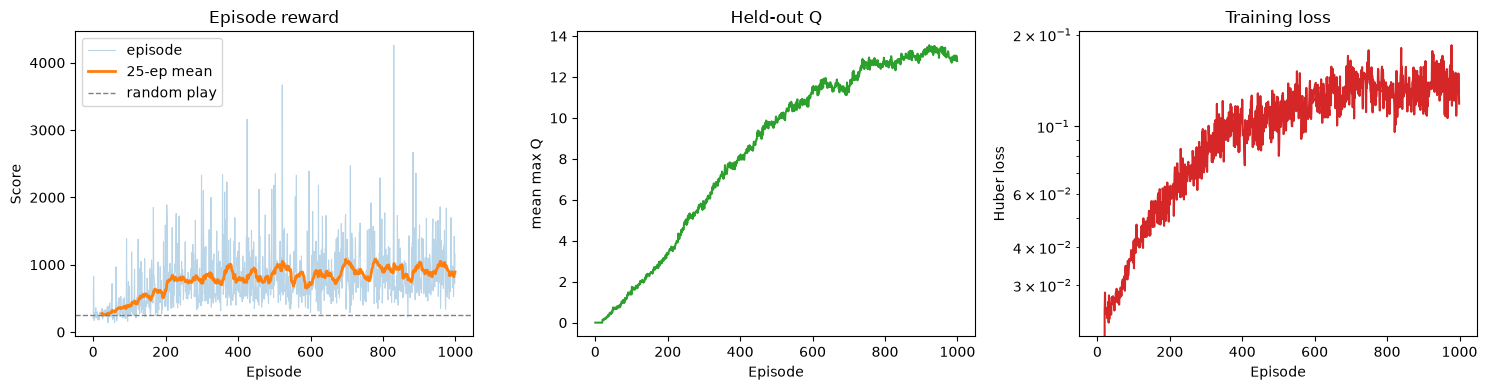

In [6]:
plot_progress(agent)
agent.record()